Graphs will be saved to: d:\DAIICT\Sem 3\NLP\Project\SarcasmLens---Subjective-Sarcasm-Detection-in-Code-Mixed-Text.-main\Baseline system\graphs

===== Dataset Information =====
Shape: (11367, 3)
Columns used: Tweet → text | Label → label

Cleaning text...
Text cleaning and word count calculation complete.


===== Word Count Statistics (by Label) =====
Label: Sarcastic (YES)
  Median Word Count: 11.0
  Mean Word Count:   11.0
Label: Non-Sarcastic (NO)
  Median Word Count: 20.0
  Mean Word Count:   19.6

Overall Dataset:
  Median Word Count: 13.0
  Mean Word Count:   14.6

Plotting class distribution...


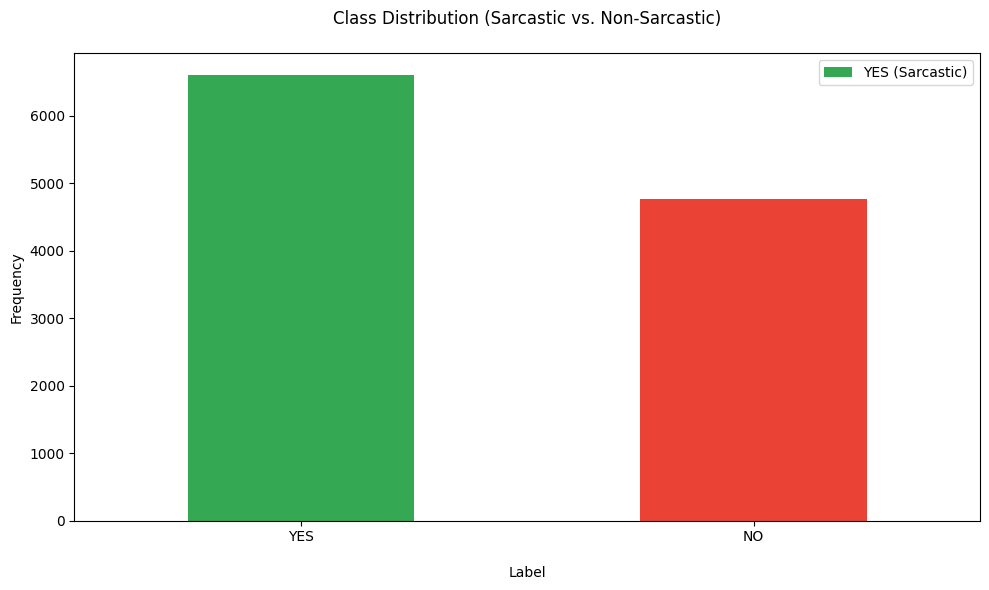

Plotting overall word count distribution...


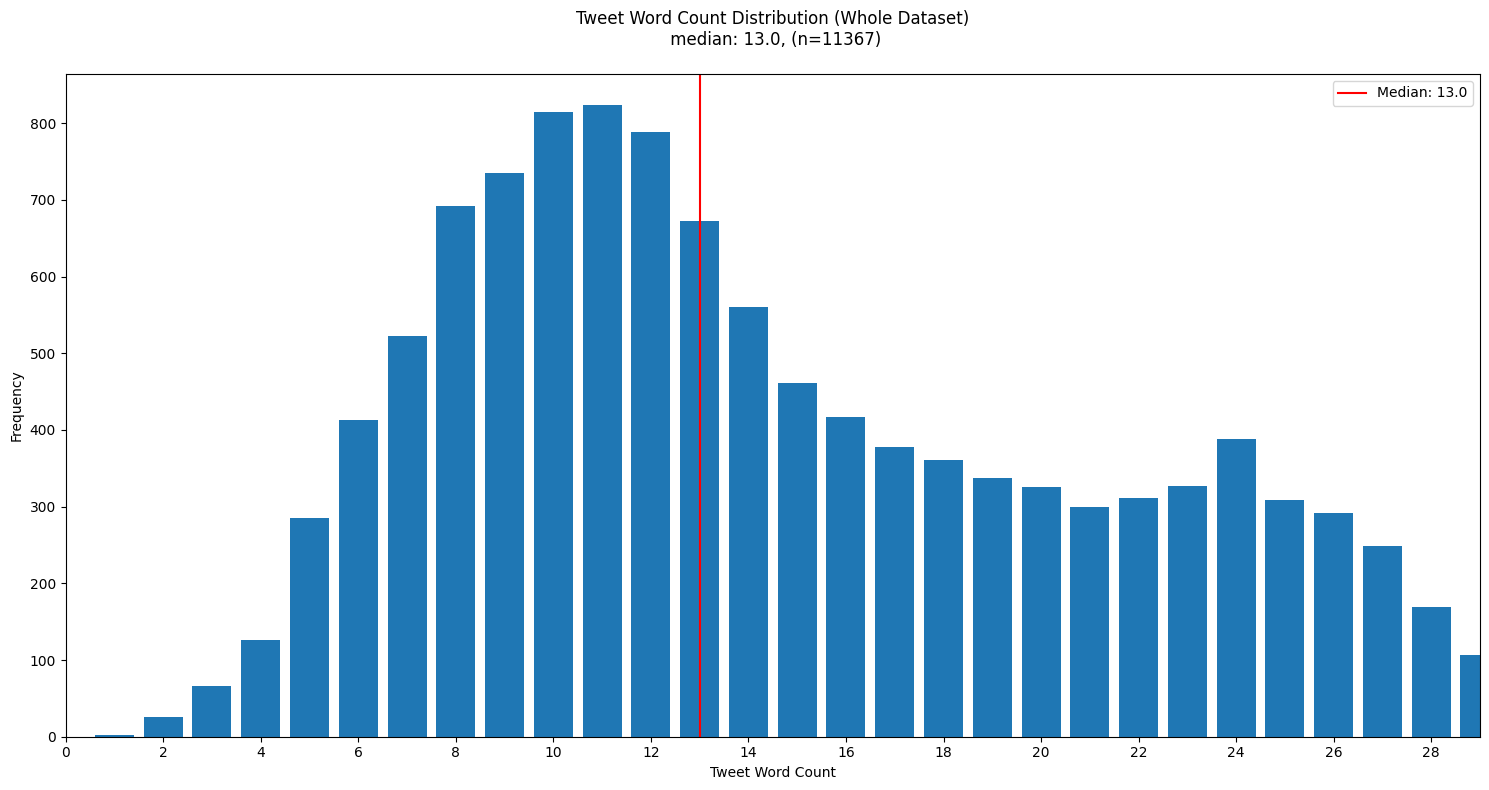

Plotting word count distribution by label...


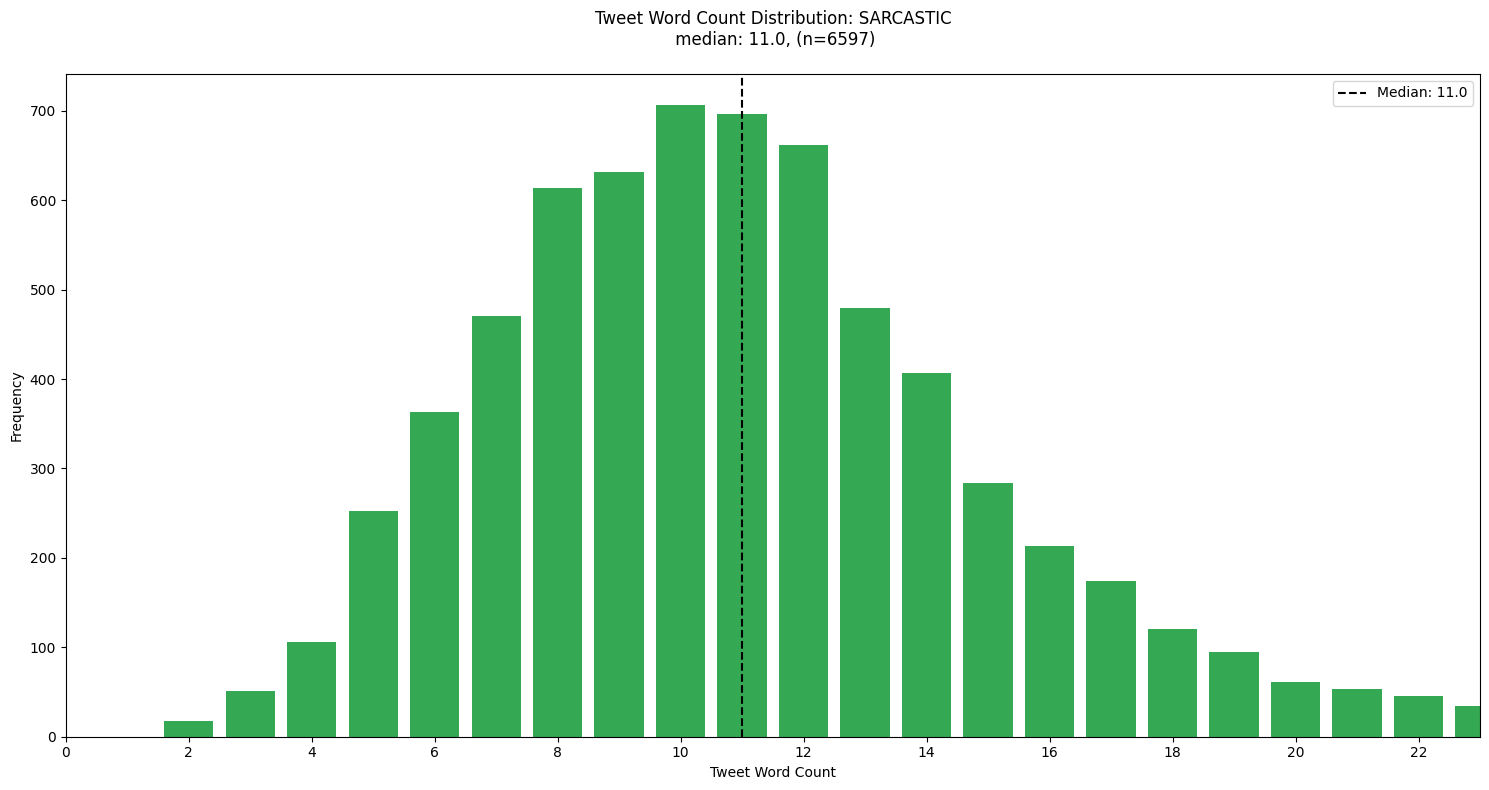

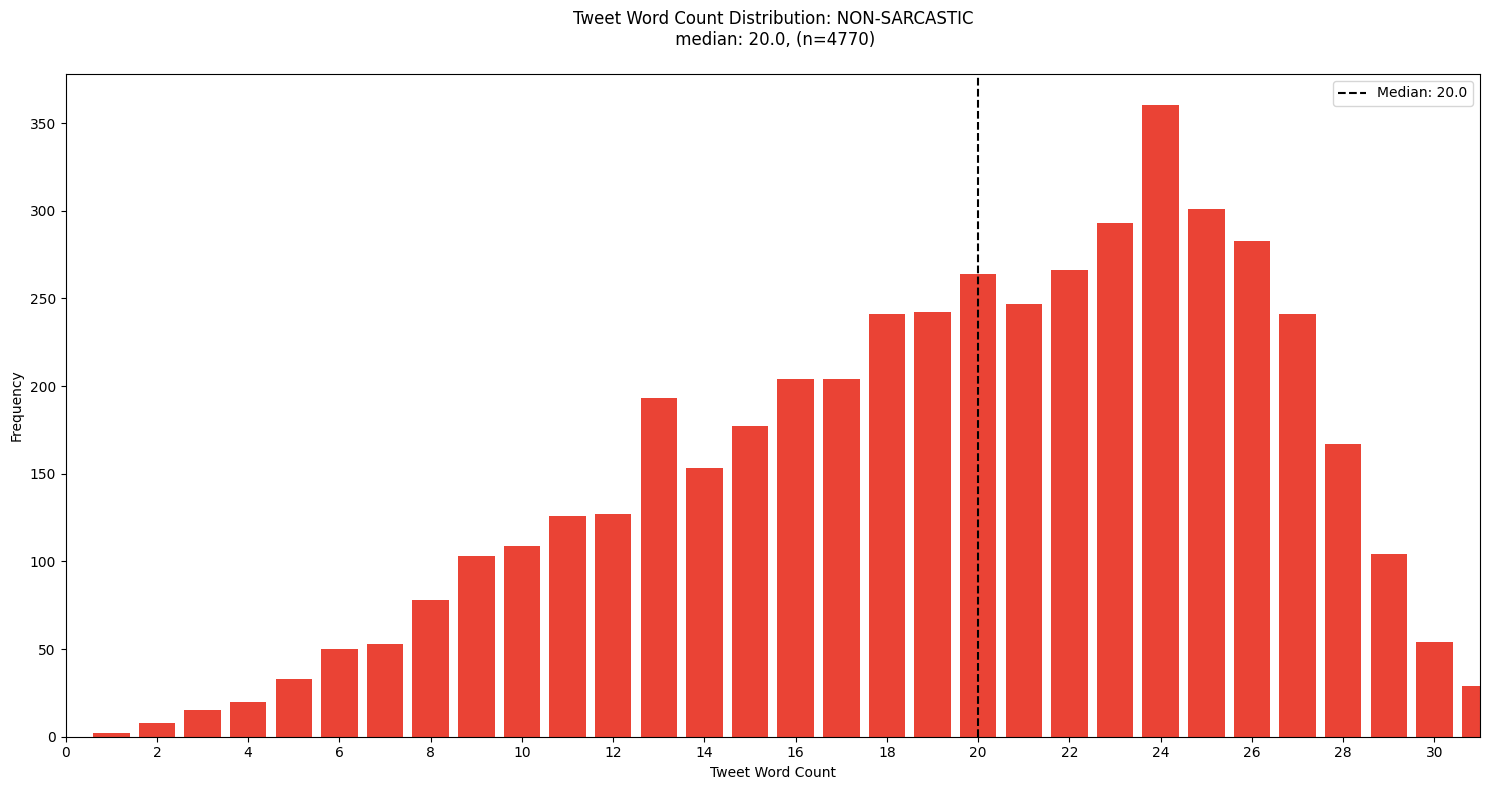


✅ Analysis complete. All graphs saved.


In [1]:
"""
SarcasmLens – Dataset Analysis
-----------------------------------------
Goal:
Analyze and visualize the properties of the SarcasmLens dataset.

This script is inspired by external analysis code and adapted for the
'unique_tweets.csv' dataset.

Analysis performed:
1.  Calculates and prints word count statistics (median, mean) for 
    sarcastic vs. non-sarcastic tweets.
2.  Plots the overall distribution of 'YES' vs. 'NO' labels.
3.  Plots the word count distribution for the entire dataset.
4.  Plots word count distributions separated by label.
"""

# =======================================================
# 1. Imports
# =======================================================
import pandas as pd
import numpy as np
import re
import os
import matplotlib.pyplot as plt

# =======================================================
# 2. Define Paths
# =======================================================
# --- IMPORTANT: Update this path to match your file location ---
DATA_PATH = r"D:\DAIICT\Sem 3\NLP\Project\SarcasmLens---Subjective-Sarcasm-Detection-in-Code-Mixed-Text.-main\Dataset\unique_tweets.csv"

CURRENT_DIRECTORY = os.getcwd()
GRAPH_PATH = os.path.join(CURRENT_DIRECTORY, "graphs")

# Create graphs directory if it doesn't exist
os.makedirs(GRAPH_PATH, exist_ok=True)
print(f"Graphs will be saved to: {GRAPH_PATH}")

# =======================================================
# 3. Load Dataset
# =======================================================
try:
    df = pd.read_csv(DATA_PATH)
except FileNotFoundError:
    print(f"Error: Could not find the dataset at {DATA_PATH}")
    print("Please update the 'DATA_PATH' variable in this script.")
    exit()

print("\n===== Dataset Information =====")
print("Shape:", df.shape)

# Automatically detect text and label columns (same as your script)
possible_text_cols = [col for col in df.columns if "tweet" in col.lower() or "text" in col.lower()]
possible_label_cols = [col for col in df.columns if "label" in col.lower()]
text_col = possible_text_cols[0] if possible_text_cols else df.columns[1]
label_col = possible_label_cols[0] if possible_label_cols else df.columns[-1]

df = df[[text_col, label_col]]
df.columns = ["text", "label"]
print(f"Columns used: {text_col} → text | {label_col} → label\n")

# =======================================================
# 4. Text Cleaning and Feature Creation
# =======================================================

# Using the exact same clean_text function from your training script
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)       # Remove URLs
    text = re.sub(r"@[A-Za-z0-9_]+", "", text)       # Remove mentions
    text = re.sub(r"#", "", text)                    # Remove hashtags
    text = re.sub(r"[^a-zA-Z\u0900-\u097F!?'\s]", " ", text)  # Keep Hindi & English
    text = re.sub(r"\s+", " ", text).strip()         # Normalize spaces
    return text

print("Cleaning text...")
df["text"] = df["text"].apply(clean_text)

# Calculate WORD COUNT (more relevant than character count)
df["word_count"] = df["text"].apply(lambda x: len(str(x).split()))
print("Text cleaning and word count calculation complete.\n")

# =======================================================
# 5. Calculate and Print Length Statistics
# =======================================================
print("\n===== Word Count Statistics (by Label) =====")
for item in ["YES", "NO"]:
    df_per_type = df.loc[df["label"] == item]
    median_word_count = np.median(df_per_type["word_count"])
    mean_word_count = round(np.mean(df_per_type["word_count"]), 1)
    label_desc = "Sarcastic" if item == "YES" else "Non-Sarcastic"
    
    print(f"Label: {label_desc} ({item})")
    print(f"  Median Word Count: {median_word_count}")
    print(f"  Mean Word Count:   {mean_word_count}")

median_word_count = np.median(df["word_count"])
mean_word_count = round(np.mean(df["word_count"]), 1)
print(f"\nOverall Dataset:")
print(f"  Median Word Count: {median_word_count}")
print(f"  Mean Word Count:   {mean_word_count}\n")


# =======================================================
# 6. Plot Class Distribution
# =======================================================
print("Plotting class distribution...")
fig = plt.figure(figsize=(10, 6))
ax = df["label"].value_counts().plot(
    kind='bar', 
    title="Class Distribution (Sarcastic vs. Non-Sarcastic)\n",
    color=["#34A853", "#EA4335"] # Green for YES, Red for NO
)
ax.set_xlabel("\nLabel")
ax.set_ylabel("Frequency")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(["YES (Sarcastic)", "NO (Non-Sarcastic)"])

# Save the plot
plt.tight_layout()
plt.savefig(os.path.join(GRAPH_PATH, "class_distribution.png"))
plt.show()


# =======================================================
# 7. Plot Word Count Distribution (Overall)
# =======================================================
print("Plotting overall word count distribution...")
df_titles = df.filter(items=["word_count", "label"])
median_length = np.median(df_titles["word_count"])
df_value_counts = df_titles["word_count"].value_counts().rename_axis("Value").reset_index(name="Frequency").sort_values("Value")

min_value = min(df_value_counts.Value)
max_value = max(df_value_counts.Value)

# Plot
fig = plt.figure(figsize = (15, 8))
plt.bar(df_value_counts.Value, df_value_counts.Frequency)
plt.xlabel("Tweet Word Count")
plt.axvline(median_length, color="red", alpha=1, label=f"Median: {median_length}")
plt.ylabel("Frequency")
# Limit x-axis for better readability, e.g., to the 99th percentile
plt.xlim(0, np.percentile(df_titles["word_count"], 99)) 
plt.locator_params(axis="x", nbins=20)
plt.title(label=f"Tweet Word Count Distribution (Whole Dataset)\n median: {median_length}, (n={len(df_titles)})\n")
plt.legend()

# Save the plot
plt.tight_layout()
plt.savefig(os.path.join(GRAPH_PATH, "word_count_whole_dataset.png"))
plt.show()         


# =======================================================
# 8. Plot Word Count Distribution (by Label)
# =======================================================
print("Plotting word count distribution by label...")
for item in ["YES", "NO"]:
    df_per_type = df_titles.loc[df_titles["label"] == item]
    median_length = np.median(df_per_type["word_count"])
    df_value_counts = df_per_type["word_count"].value_counts().rename_axis("Value").reset_index(name="Frequency").sort_values("Value")
    
    label_type = "sarcastic" if item == "YES" else "non-sarcastic"
    plot_color = "#34A853" if item == "YES" else "#EA4335"

    min_value = min(df_value_counts.Value)
    max_value = max(df_value_counts.Value)

    # Plot
    fig = plt.figure(figsize = (15, 8))
    plt.bar(df_value_counts.Value, df_value_counts.Frequency, color=plot_color)
    plt.xlabel("Tweet Word Count")
    plt.axvline(median_length, color="black", linestyle="--", alpha=1, label=f"Median: {median_length}")
    plt.ylabel("Frequency")
    # Limit x-axis for better readability
    plt.xlim(0, np.percentile(df_per_type["word_count"], 99)) 
    plt.locator_params(axis="x", nbins=20)
    plt.title(label=f"Tweet Word Count Distribution: {label_type.upper()}\n median: {median_length}, (n={len(df_per_type)})\n")
    plt.legend()

    # Save the plot
    plt.tight_layout()
    plt.savefig(os.path.join(GRAPH_PATH, f"word_count_{label_type}.png"))
    plt.show()

print("\n✅ Analysis complete. All graphs saved.")